# PINN pour un circuit RC-AC avec une perte physique 
### Decomment 2nd block of code for consistent initialising seed
### Network trained with dataset used ***without DataLoader***

<u>Import nécessaire :</u>

In [16]:
import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import csv 
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
import joblib

In [17]:
# Initialise random seed for model weights and activations

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # If using torch.backends (optional for CPU, more relevant for CUDA)
    if torch.backends.mps.is_available():
        torch.use_deterministic_algorithms(True)

set_seed(42)

In [18]:
# A  COMPLETER AVEC LE NOM DU FICHIER CSV
df = pd.read_csv( "rc_ac_results_12500L.csv" )
#print(df)
print( df.shape )

(75125, 12)


In [19]:

# Data normalisation

# Extraction des colonnes d'entrée X (R, C, Vin, Frequency) sous forme de tableau NumPy
X = df[ [ "R" , "C" , "Vin" , "Frequency" ] ].values

# Extraction des colonnes d'entrée X (R, C, Vin, Frequency) sous forme de tableau NumPy
Y = df[ [ "Gain_basse", "Gain_haute" , "Phase_R" , "Phase_C" ] ].values

# Extraction individuelle des sorties pour un traitement ou entraînement spécifique par cible
Y_GB = df[ [ "Gain_basse" ] ].values
Y_GH = df[ [ "Gain_haute" ] ].values
Y_PR = df[ [ "Phase_R" ] ].values
Y_PC = df[ [ "Phase_C" ] ].values

# Initialisation d’un objet de normalisation pour les entrées
scaler_x = StandardScaler()

# Initialisation d’un objet de normalisation pour les sorties combinées
scaler_y = StandardScaler()

# Initialisation de normaliseurs séparés pour chaque sortie individuelle
scaler_y_GB = StandardScaler()
scaler_y_GH = StandardScaler()
scaler_y_PR = StandardScaler()
scaler_y_PC = StandardScaler()


# Transformation des entrées normalisées en tenseur PyTorch
X_tensor = torch.tensor( scaler_x.fit_transform(X) , dtype = torch.float32 )

#######
# Transformation de toutes les sorties normalisées en un seul tenseur
Y_tensor = torch.tensor( scaler_y.fit_transform(Y) , dtype = torch.float32 )
#######

# Transformation des sorties individuelles (chacune normalisée séparément) en tenseurs
Y_tensor_GB = torch.tensor( scaler_y_GB.fit_transform(Y_GB) , dtype = torch.float32 )
Y_tensor_GH = torch.tensor( scaler_y_GH.fit_transform(Y_GH) , dtype = torch.float32 )
Y_tensor_PR = torch.tensor( scaler_y_PR.fit_transform(Y_PR) , dtype = torch.float32 )
Y_tensor_PC = torch.tensor( scaler_y_PC.fit_transform(Y_PC) , dtype = torch.float32 )


# Création d'un ensemble de données complet (X et Y combinés) pour entraînement
dataset = TensorDataset( X_tensor , Y_tensor )

# Création de jeux de données pour entraînement indépendant par sortie (utile pour évaluer ou entraîner un PINN spécifique)
dataset_GB = TensorDataset( X_tensor , Y_tensor_GB )
dataset_GH = TensorDataset( X_tensor , Y_tensor_GH )
dataset_PR = TensorDataset( X_tensor , Y_tensor_PR )
dataset_PC = TensorDataset( X_tensor , Y_tensor_PC )

# Création d’un DataLoader pour itérer sur les données pendant l'entraînement 
loader = DataLoader(dataset, batch_size=256, shuffle=True)

# Accès aux colonnes individuelles R, C, Frequency depuis le tenseur d’entrée
R = X_tensor[ :,0 ]
C = X_tensor[ :,1 ]
Frequency = X_tensor[ :,3 ]


print( R )
print( C )

print( ( R*C ).shape )

tensor([-1.0196, -1.0196, -1.0196,  ...,  1.7504,  1.7504,  1.7504])
tensor([-0.7601, -0.7601, -0.7601,  ...,  1.9125,  1.9125,  1.9125])
torch.Size([75125])


In [20]:
class RegressionModel(nn.Module):
    def __init__( self , in_features , out_features = 4 ):
        super().__init__()

        """"
        nn.Linear( a , b ) crée une couche fully connected

            a : neurones en input
            b : neurones en output
        """
        self.fc1 = nn.Linear( in_features , 64 )
        self.fc2 = nn.Linear( 64 , 64 )
        self.fc3 = nn.Linear( 64 , 64 )
        self.fc4 = nn.Linear( 64 , 64 )
        self.fc5 = nn.Linear( 64 , 64 )
        self.fc6 = nn.Linear( 64 , out_features )
        


    def forward( self , x ): # Définition du passage avant (forward pass)
        x = F.tanh( self.fc1( x ) )
        x = F.tanh( self.fc2( x ) )
        x = F.tanh( self.fc3( x ) )
        x = F.tanh( self.fc4( x ) )
        x = F.tanh( self.fc5( x ) )
        x = self.fc6( x )  # No activation on output for regression
        return x

In [21]:
in_features = 4
out_features = 4

# Instanciation du modèle de régression
model = RegressionModel( in_features , out_features )

# Fonction de perte : Mean Squared Error, adaptée à la régression
criterion = nn.MSELoss()

# Optimiseur Adam
optimizer = optim.Adam( model.parameters() , lr = 1e-5 )


In [22]:
# Function to compute the PDE residual pour gain basse : 

def pde_residual(model, x, out):

    # Clone les entrées, les détache du graph, et active le calcul du gradient pour autograd
    x = x.clone().detach().requires_grad_(True)

    # Dénormalise les features (R, C, Vin, Frequency) pour les utiliser dans les formules physiques
    x_denorm = torch.tensor(scaler_x.inverse_transform(x.detach().cpu().numpy()), dtype=torch.float32)
    
    # Prédiction du modèle
    u = model(x)

    # Récupère les colonnes dénormalisées
    R = x_denorm[:, 0]
    C = x_denorm[:, 1]
    Vin = x_denorm[:, 2]
    Frequency = x_denorm[:, 3]
    w = 2 * torch.pi * Frequency # pulsation

    # Calcul de la cible physique selon le nom de sortie
    if out == "Gain_basse":

        u_model = u[:, 0] # Sortie prédite pour le gain basse fréquence
        u_phys = 1 / torch.sqrt(1 + (w * R * C) ** 2) # Formule théorique

    elif out == "Gain_haute":

        u_model = u[:, 1] # Sortie prédite pour le gain haute fréquence
        u_phys = 1 / torch.sqrt(1 + (w * R * C) ** 2) # Formule théorique

    elif out == "Phase_R":

        u_model = u[:, 2] # Sortie prédite pour la phase R
        u_phys = torch.atan(w * R * C) # Formule théorique


    elif out == "Phase_C":

        u_model = u[:, 3] # Sortie prédite pour la phase C
        u_phys = -torch.atan(w * R * C) # Formule théorique

    else:
        # Si le nom de la sortie n'est pas reconnu, on déclenche une erreur explicite
        raise ValueError("Sortie non valide.")

    residual = (u_model - u_phys) ** 2
    return torch.mean(residual)


#pde_test = pde_residual(model, X_tensor)
#print(pde_test)
#print(pde_test.shape)



In [23]:
nb_epochs = 200

# Listes pour stocker les pertes (loss) pour chaque sortie du réseau

losses_GH = []
losses_GB = []
losses_PR = []
losses_PC = []

loss = []

# Before training
#set_seed(42)

# Met le modèle en mode entraînement
model.train()

ld = 0.05 # Facteur de pondération de la perte physique (lambda)
alpha = 0.95 # Facteur de pondération de la perte MSE (alpha)


window = 500  # taille de la moyenne glissante

for i in range(nb_epochs): # Boucle principale d'entraînement sur nb_epochs itérations

    
    for X_batch, Y_batch in loader: # Boucle sur les mini-batchs de données
        
        # Passe les données d'entrée dans le modèle
        outputs = model(X_batch)

        # Dénormalise les features pour pouvoir appliquer les équations physiques
        X_batch_denorm = torch.tensor(
            scaler_x.inverse_transform(X_batch.detach().cpu().numpy()), 
            dtype=torch.float32
        )

        # Extrait les colonnes dénormalisées nécessaires aux équations physiques
        R = X_batch_denorm[:, 0]
        C = X_batch_denorm[:, 1]
        Frequency = X_batch_denorm[:, 3]
        w = 2 * torch.pi * Frequency

        # Physics loss (avec .detach() sur outputs)
        #R = X_batch[:, 0]
        #C = X_batch[:, 1]
        #Frequency = X_batch[:, 3]
        #w = 2 * torch.pi * Frequency

        gain_basse_th = 1 / torch.sqrt(1 + (w * R * C) ** 2)
        gain_haute_th = 1 / torch.sqrt(1 + (w * R * C) ** 2)
        phase_R_th = torch.atan(w * R * C)
        phase_C_th = -torch.atan(w * R * C)

        # Calcul de la perte physique (PINN) pour chaque sortie à partir des équations connues
        loss_physics_GB = pde_residual(model, X_batch, "Gain_basse")
        loss_physics_GH = pde_residual(model, X_batch, "Gain_haute")
        loss_physics_PR = pde_residual(model, X_batch, "Phase_R")
        loss_physics_PC = pde_residual(model, X_batch, "Phase_C")

        # Calcul de la perte physique totale
        loss_phys = loss_physics_GB + loss_physics_GH + loss_physics_PR + loss_physics_PC

        # MSE loss

        # Calcul des pertes MSE (Mean Squared Error) pour chaque sortie
        loss_mse_GB = criterion(outputs[:, 0:1], Y_batch[:, 0:1])
        loss_mse_GH = criterion(outputs[:, 1:2], Y_batch[:, 1:2])
        loss_mse_PR = criterion(outputs[:, 2:3], Y_batch[:, 2:3])
        loss_mse_PC = criterion(outputs[:, 3:4], Y_batch[:, 3:4])
        
        # Perte MSE globale sur toutes les sorties
        loss_mse = criterion(outputs, Y_batch)

        # Total loss par sortie
        # Combinaison de la perte MSE et de la perte physique pour chaque sortie
        loss_GB = loss_mse_GB + ld * loss_physics_GB
        loss_GH = loss_mse_GH + ld * loss_physics_GH
        loss_PR = loss_mse_PR + ld * loss_physics_PR
        loss_PC = loss_mse_PC + ld * loss_physics_PC

        # Perte globale principale
        loss_total_princ = alpha * loss_mse + ld * loss_phys

        # Backward
        total_loss = loss_GB + loss_GH + loss_PR + loss_PC

        # Réinitialisation des gradients avant backward
        optimizer.zero_grad()
        total_loss.backward() # Propagation du gradient
        optimizer.step() # Mise à jour des poids par l'optimiseur Adam


        # Enregistrement des pertes pour affichage ultérieur
        losses_GB.append(loss_GB.item())
        losses_GH.append(loss_GH.item())
        losses_PR.append(loss_PR.item())
        losses_PC.append(loss_PC.item())

        loss.append(loss_total_princ.item())

        # Affichage des pertes tous les 25 epochs
        if ( i % 25 == 0 ):
            print(f'Epoch [{i+1}], Loss: {loss_GB.item():.9f}')
            print(f'Epoch [{i+1}], Loss: {loss_GH.item():.9f}')
            print(f'Epoch [{i+1}], Loss: {loss_PR.item():.9f}')
            print(f'Epoch [{i+1}], Loss: {loss_PC.item():.9f}')
            print()


Epoch [1], Loss: 1.017544150
Epoch [1], Loss: 1.009385109
Epoch [1], Loss: 1.067601085
Epoch [1], Loss: 1.039885521

Epoch [1], Loss: 1.030322433
Epoch [1], Loss: 1.064410210
Epoch [1], Loss: 1.090636730
Epoch [1], Loss: 1.073015809

Epoch [1], Loss: 1.038054109
Epoch [1], Loss: 1.071732640
Epoch [1], Loss: 1.109340191
Epoch [1], Loss: 1.082410097

Epoch [1], Loss: 1.045460105
Epoch [1], Loss: 1.058701634
Epoch [1], Loss: 1.107692838
Epoch [1], Loss: 1.078478456

Epoch [1], Loss: 1.007738352
Epoch [1], Loss: 1.032860875
Epoch [1], Loss: 1.076039553
Epoch [1], Loss: 1.044197798

Epoch [1], Loss: 1.000686765
Epoch [1], Loss: 1.019747615
Epoch [1], Loss: 1.056374311
Epoch [1], Loss: 1.029478908

Epoch [1], Loss: 1.038967371
Epoch [1], Loss: 1.028820634
Epoch [1], Loss: 1.092505455
Epoch [1], Loss: 1.059974313

Epoch [1], Loss: 0.990531266
Epoch [1], Loss: 1.049826503
Epoch [1], Loss: 1.042277932
Epoch [1], Loss: 1.035462141

Epoch [1], Loss: 1.058186412
Epoch [1], Loss: 1.006669641
Epoch 

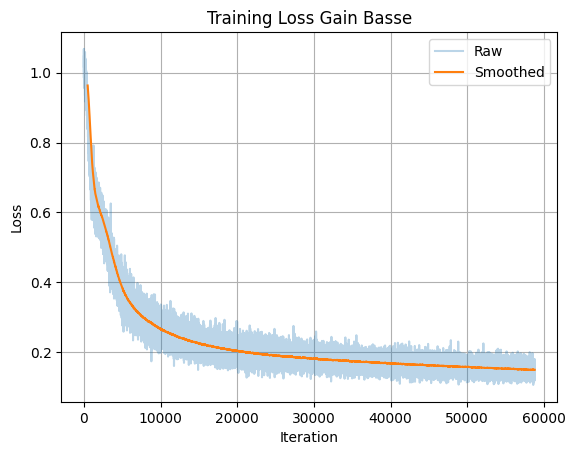

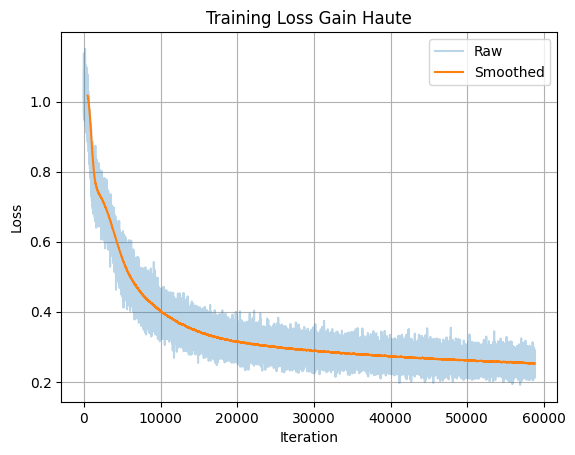

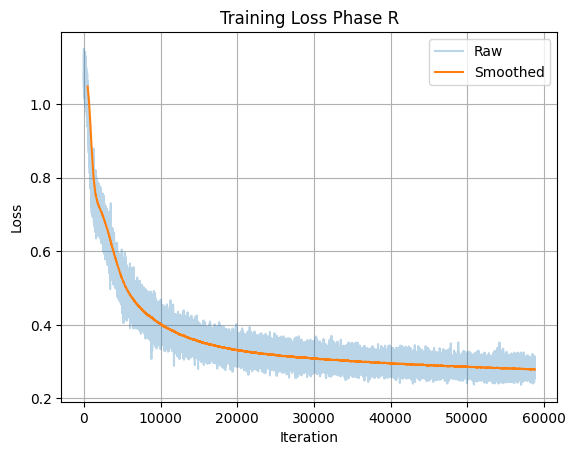

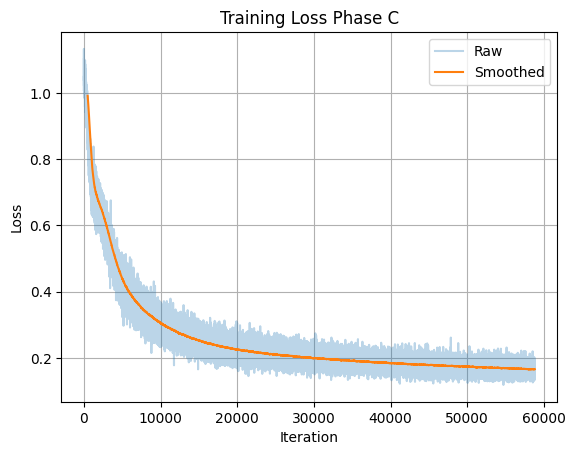

In [24]:

# Courbes de perte

# Gain basse
plt.figure()
plt.plot(losses_GB, alpha=0.3, label="Raw") # Trace la courbe brute (non lissée) de la perte Gain_basse avec transparence
plt.plot(pd.Series(losses_GB).rolling(window).mean(), label="Smoothed") # Trace la courbe lissée de la perte Gain_basse
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Gain Basse')
plt.legend()
plt.grid(True)
plt.show()



# Gain haute
plt.figure()
plt.plot(losses_GH, alpha=0.3, label="Raw")
plt.plot(pd.Series(losses_GH).rolling(window).mean(), label="Smoothed")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Gain Haute')
plt.legend()
plt.grid(True)
plt.show()

# Phase R
plt.figure()
plt.plot(losses_PR, alpha=0.3, label="Raw")
plt.plot(pd.Series(losses_PR).rolling(window).mean(), label="Smoothed")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Phase R')
plt.legend()
plt.grid(True)
plt.show()

# Phase C
plt.figure()
plt.plot(losses_PC, alpha=0.3, label="Raw")
plt.plot(pd.Series(losses_PC).rolling(window).mean(), label="Smoothed")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Phase C')
plt.legend()
plt.grid(True)
plt.show()

Loss GB : 0.124
Loss GH : 0.160
Loss PR : 0.132
Loss PC : 0.123


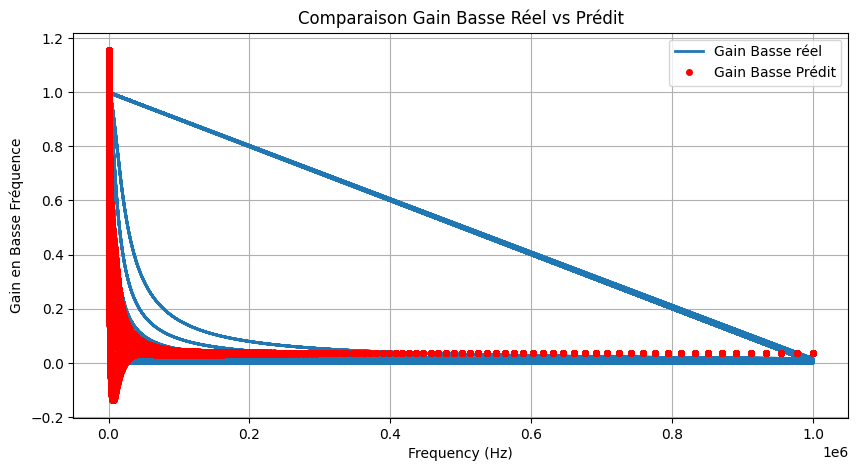

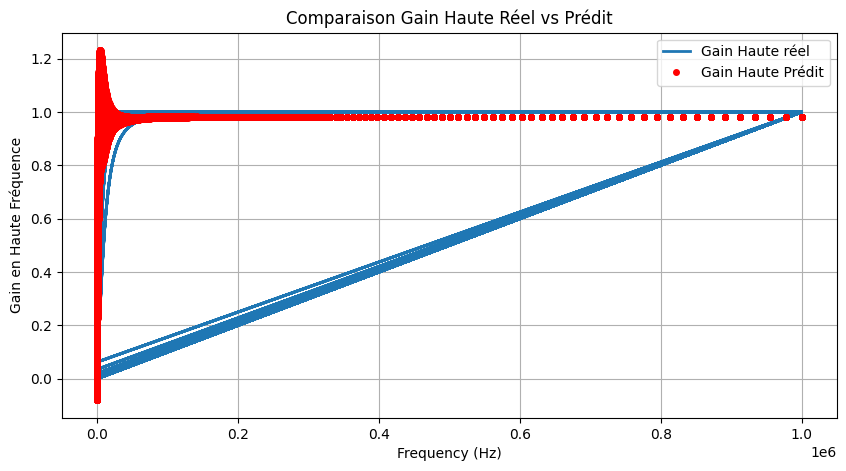

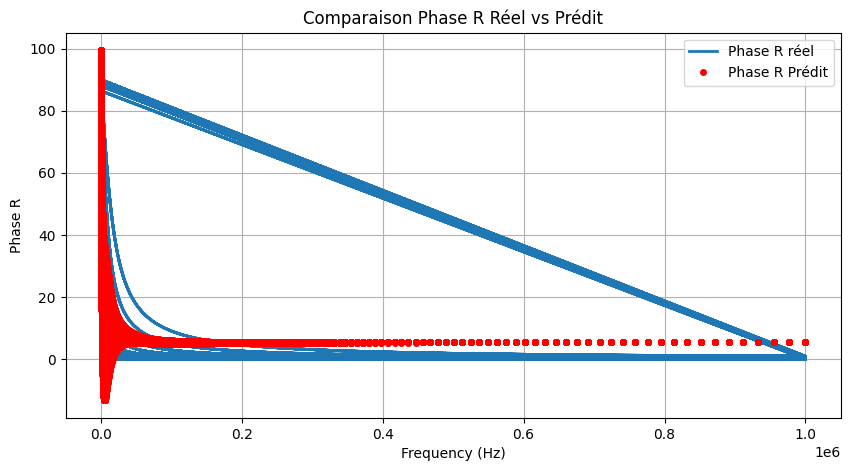

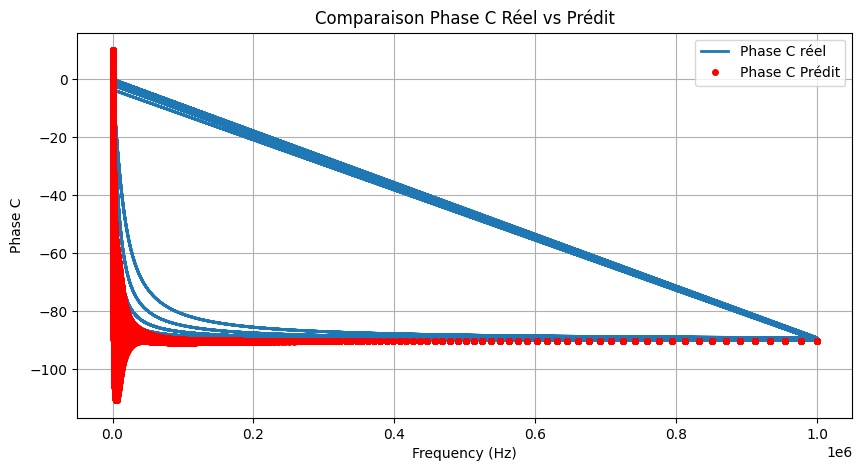

In [25]:
# Met le modèle en mode évaluation
model.eval()

with torch.no_grad():
    # Prédictions (N, 4)
    # Prédictions du modèle (N, 4) sur tout l'ensemble normalisé
    predictions = model(X_tensor).cpu().numpy()

    # Séparation des prédictions en 4 sorties distinctes
    predictions_GB = predictions[:, 0:1]
    predictions_GH = predictions[:, 1:2]
    predictions_PR = predictions[:, 2:3]
    predictions_PC = predictions[:, 3:4]

    
    # Calcul des pertes MSE entre prédictions et vraies valeurs (normalisées)
    loss_GB = criterion(torch.tensor(predictions_GB), Y_tensor_GB)
    loss_GH = criterion(torch.tensor(predictions_GH), Y_tensor_GH)
    loss_PR = criterion(torch.tensor(predictions_PR), Y_tensor_PR)
    loss_PC = criterion(torch.tensor(predictions_PC), Y_tensor_PC)

    # Affichage des pertes pour chaque sortie
    print(f"Loss GB : {loss_GB.item():.3f}")
    print(f"Loss GH : {loss_GH.item():.3f}")
    print(f"Loss PR : {loss_PR.item():.3f}")
    print(f"Loss PC : {loss_PC.item():.3f}")

    
    # Dénormalisation des prédictions pour chaque sortie
    predictions_original_GB = scaler_y_GB.inverse_transform(predictions_GB)
    predictions_original_GH = scaler_y_GH.inverse_transform(predictions_GH)
    predictions_original_PR = scaler_y_PR.inverse_transform(predictions_PR)
    predictions_original_PC = scaler_y_PC.inverse_transform(predictions_PC)

    # Dénormalisation des vraies valeurs
    Y_true_original_GB = scaler_y_GB.inverse_transform(Y_tensor_GB.numpy())
    Y_true_original_GH = scaler_y_GH.inverse_transform(Y_tensor_GH.numpy())
    Y_true_original_PR = scaler_y_PR.inverse_transform(Y_tensor_PR.numpy())
    Y_true_original_PC = scaler_y_PC.inverse_transform(Y_tensor_PC.numpy())

    # Dénormalisation des fréquences
    frequencies = scaler_x.inverse_transform(X_tensor.numpy())[:, 3]


# Affichage des courbes comparant vraies valeurs vs prédictions

# Tracé Gain Basse
plt.figure(figsize=(10, 5))
plt.plot(frequencies, Y_true_original_GB[:, 0], label="Gain Basse réel", linewidth=2)
plt.plot(frequencies, predictions_original_GB[:, 0], 'o', label="Gain Basse Prédit", markersize=4, color='red')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain en Basse Fréquence")
plt.title("Comparaison Gain Basse Réel vs Prédit")
plt.legend()
plt.grid(True)
plt.show()

# Tracé Gain Haute
plt.figure(figsize=(10, 5))
plt.plot(frequencies, Y_true_original_GH[:, 0], label="Gain Haute réel", linewidth=2)
plt.plot(frequencies, predictions_original_GH[:, 0], 'o', label="Gain Haute Prédit", markersize=4, color='red')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain en Haute Fréquence")
plt.title("Comparaison Gain Haute Réel vs Prédit")
plt.legend()
plt.grid(True)
plt.show()

# Tracé Phase R
plt.figure(figsize=(10, 5))
plt.plot(frequencies, Y_true_original_PR[:, 0], label="Phase R réel", linewidth=2)
plt.plot(frequencies, predictions_original_PR[:, 0], 'o', label="Phase R Prédit", markersize=4, color='red')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase R")
plt.title("Comparaison Phase R Réel vs Prédit")
plt.legend()
plt.grid(True)
plt.show()

# Tracé Phase C
plt.figure(figsize=(10, 5))
plt.plot(frequencies, Y_true_original_PC[:, 0], label="Phase C réel", linewidth=2)
plt.plot(frequencies, predictions_original_PC[:, 0], 'o', label="Phase C Prédit", markersize=4, color='red')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase C")
plt.title("Comparaison Phase C Réel vs Prédit")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# Print model's state_dict
print( "Model's state_dict:" )
for param_tensor in model.state_dict():
    print( param_tensor, "\t", model.state_dict()[ param_tensor ].size() )

# Print optimizer's state_dict
"""print("Optimizer's state_dict:")
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])"""



Model's state_dict:
fc1.weight 	 torch.Size([64, 4])
fc1.bias 	 torch.Size([64])
fc2.weight 	 torch.Size([64, 64])
fc2.bias 	 torch.Size([64])
fc3.weight 	 torch.Size([64, 64])
fc3.bias 	 torch.Size([64])
fc4.weight 	 torch.Size([64, 64])
fc4.bias 	 torch.Size([64])
fc5.weight 	 torch.Size([64, 64])
fc5.bias 	 torch.Size([64])
fc6.weight 	 torch.Size([4, 64])
fc6.bias 	 torch.Size([4])


'print("Optimizer\'s state_dict:")\nfor var_name in optimizer.state_dict():\n    print(var_name, "\t", optimizer.state_dict()[var_name])'

<u>Trier les données par fréquence et moyenner les prédictions pour chaque fréquence </u>

GB

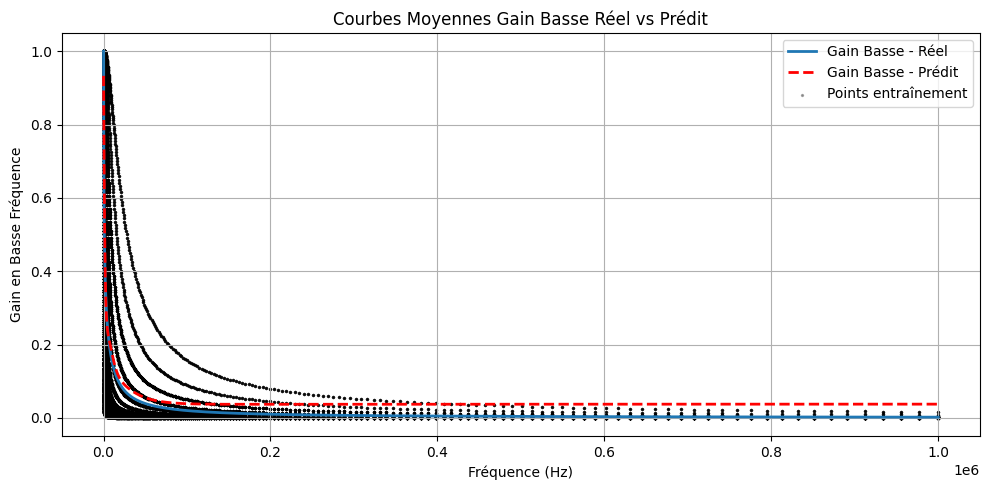

In [27]:
# Récupération des fréquences dénormalisées et des valeurs (réelles et prédites)
frequencies = scaler_x.inverse_transform(X_tensor.numpy())[:, 3]
gain_basse_true = Y_true_original_GB[:, 0]
gain_basse_pred = predictions_original_GB[:, 0]

# Créer un DataFrame pour regrouper et moyenner par fréquence
df_plot = pd.DataFrame({
    "Frequency": frequencies,
    "Gain_basse_true": gain_basse_true,
    "Gain_basse_pred": gain_basse_pred
})

# Regroupement par fréquence (moyenne pour chaque fréquence)
df_mean = df_plot.groupby("Frequency").mean().reset_index()

# Affichage de la courbe unique
plt.figure(figsize=(10, 5))
plt.plot(df_mean["Frequency"], df_mean["Gain_basse_true"], label="Gain Basse - Réel", linewidth=2)
plt.plot(df_mean["Frequency"], df_mean["Gain_basse_pred"], label="Gain Basse - Prédit", linewidth=2, linestyle='--', color='red')



plt.scatter(frequencies, gain_basse_true, color='black', s=2, alpha=0.3, label="Points entraînement")


plt.xlabel("Fréquence (Hz)")
plt.ylabel("Gain en Basse Fréquence")
plt.title("Courbes Moyennes Gain Basse Réel vs Prédit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




GH

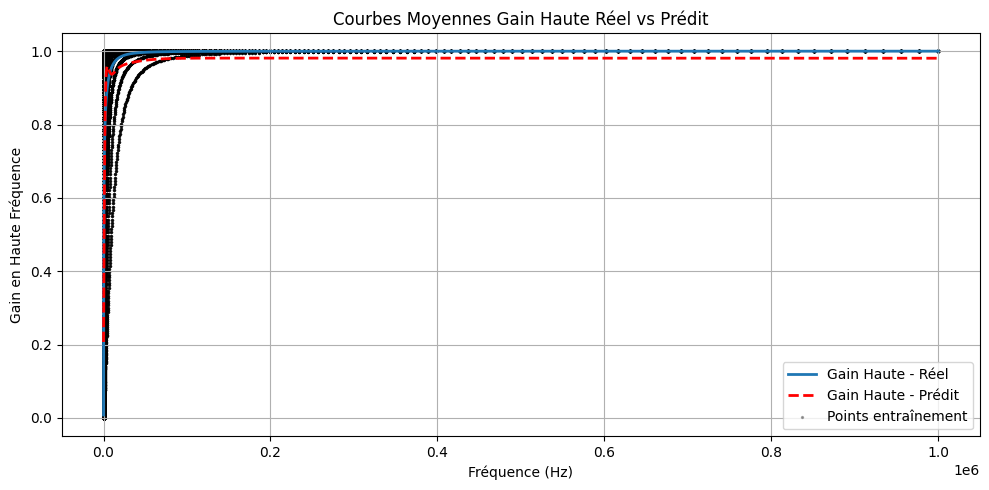

In [28]:
import pandas as pd

# Récupération des fréquences dénormalisées et des valeurs (réelles et prédites)
frequencies = scaler_x.inverse_transform(X_tensor.numpy())[:, 3]
gain_haute_true = Y_true_original_GH[:, 0]
gain_haute_pred = predictions_original_GH[:, 0]

# Créer un DataFrame pour regrouper et moyenner par fréquence
df_plot = pd.DataFrame({
    "Frequency": frequencies,
    "Gain_haute_true": gain_haute_true,
    "Gain_haute_pred": gain_haute_pred
})

# Regroupement par fréquence (moyenne pour chaque fréquence)
df_mean = df_plot.groupby("Frequency").mean().reset_index()

# Affichage de la courbe unique
plt.figure(figsize=(10, 5))
plt.plot(df_mean["Frequency"], df_mean["Gain_haute_true"], label="Gain Haute - Réel", linewidth=2)
plt.plot(df_mean["Frequency"], df_mean["Gain_haute_pred"], label="Gain Haute - Prédit", linewidth=2, linestyle='--', color='red')


plt.scatter(frequencies, gain_haute_true, color='black', s=2, alpha=0.3, label="Points entraînement")


plt.xlabel("Fréquence (Hz)")
plt.ylabel("Gain en Haute Fréquence")
plt.title("Courbes Moyennes Gain Haute Réel vs Prédit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


PR

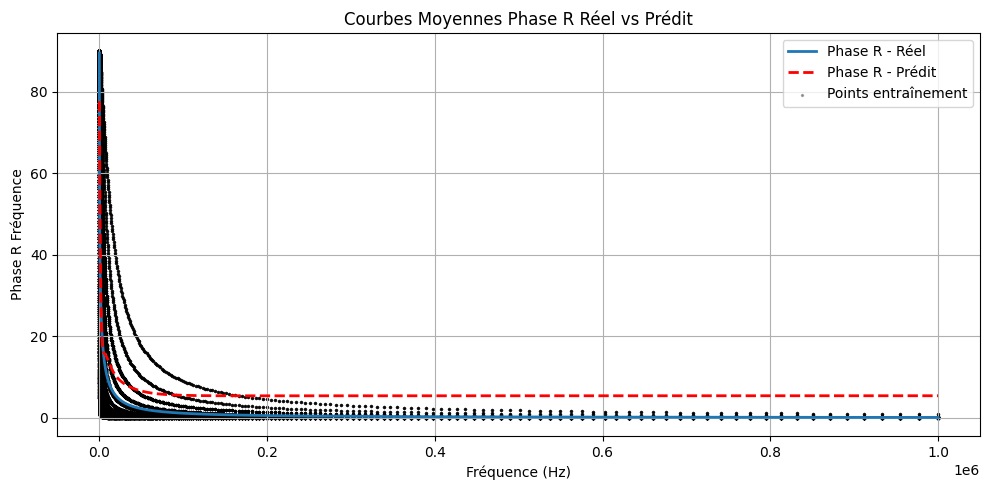

In [29]:
import pandas as pd

# Récupération des fréquences dénormalisées et des valeurs (réelles et prédites)
frequencies = scaler_x.inverse_transform(X_tensor.numpy())[:, 3]
phase_r_true = Y_true_original_PR[:, 0]
phase_r_pred = predictions_original_PR[:, 0]

# Créer un DataFrame pour regrouper et moyenner par fréquence
df_plot = pd.DataFrame({
    "Frequency": frequencies,
    "Phase_r_true": phase_r_true,
    "Phase_r_pred": phase_r_pred
})

# Regroupement par fréquence (moyenne pour chaque fréquence)
df_mean = df_plot.groupby("Frequency").mean().reset_index()

# Affichage de la courbe unique
plt.figure(figsize=(10, 5))
plt.plot(df_mean["Frequency"], df_mean["Phase_r_true"], label="Phase R - Réel", linewidth=2)
plt.plot(df_mean["Frequency"], df_mean["Phase_r_pred"], label="Phase R - Prédit", linewidth=2, linestyle='--', color='red')


plt.scatter(frequencies, phase_r_true, color='black', s=2, alpha=0.3, label="Points entraînement")

plt.xlabel("Fréquence (Hz)")
plt.ylabel("Phase R Fréquence")
plt.title("Courbes Moyennes Phase R Réel vs Prédit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


PC

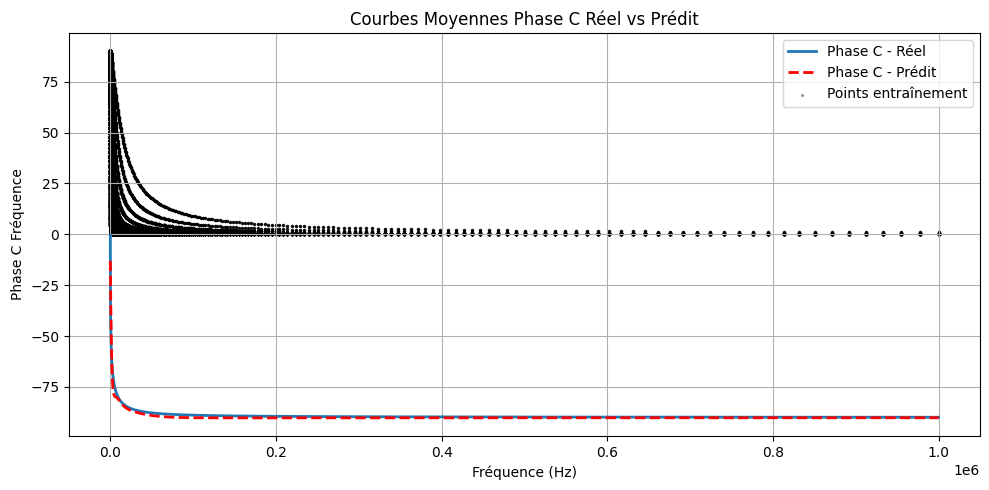

In [30]:
import pandas as pd

# Récupération des fréquences dénormalisées et des valeurs (réelles et prédites)
frequencies = scaler_x.inverse_transform(X_tensor.numpy())[:, 3]
phase_c_true = Y_true_original_PC[:, 0]
phase_c_pred = predictions_original_PC[:, 0]

# Créer un DataFrame pour regrouper et moyenner par fréquence
df_plot = pd.DataFrame({
    "Frequency": frequencies,
    "Phase_c_true": phase_c_true,
    "Phase_c_pred": phase_c_pred
})

# Regroupement par fréquence (moyenne pour chaque fréquence)
df_mean = df_plot.groupby("Frequency").mean().reset_index()

# Affichage de la courbe unique
plt.figure(figsize=(10, 5))
plt.plot(df_mean["Frequency"], df_mean["Phase_c_true"], label="Phase C - Réel", linewidth=2)
plt.plot(df_mean["Frequency"], df_mean["Phase_c_pred"], label="Phase C - Prédit", linewidth=2, linestyle='--', color='red')


plt.scatter(frequencies, phase_r_true, color='black', s=2, alpha=0.3, label="Points entraînement")



plt.xlabel("Fréquence (Hz)")
plt.ylabel("Phase C Fréquence")
plt.title("Courbes Moyennes Phase C Réel vs Prédit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
